# CA1 - Data Preparation
**Student name:** Gleiciane Rocha dos Santos
**Student ID:** 2026248  
**Module:** Data Preparation  
**Programme:** HDIP Data Analytics  
**Dataset:** student_data.csv




## Introduction

This notebook looks at the dataset `student_data.csv`, which contains information about students and their outcomes, the aim of this analysis is to understand the dataset, improve its quality, prepare it for analysis, identify patterns in the data, and use PCA to reduce dimensionality while keeping most of the information. 
It also discusses the curse of dimensionality and checks whether the reduced dataset is still useful in practice.

## Dataset Characterisation

In [61]:
import pandas as pd
import numpy as np

In [62]:
df = pd.read_csv("student_data.csv")

The dataset was loaded into Python using pandas

In [63]:
df.shape

(4424, 37)

The dataset has 4424 rows and 37 columns. This gives a general idea of the size of the data used in this analysis

In [64]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [65]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

The columns names were checked to understand wich varibles are included in the dataset and confirm the presence of the target variable 

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4423 non-null   float64
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

Info output helped to check the structure, especially variables types and any possible missing values

In [67]:
df.isna().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            1
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            1
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   1
Displaced                                         0
Educational special needs                         0
Debtor                                            1
Tuition fees up to date                           1
Gender                                            0
Scholarship holder                                0
Age at enrol

Missing values were checked to see any variable had imcomplete data

In [68]:
df["Target"].value_counts(dropna=False)

Target
Graduate    2207
Dropout     1419
Enrolled     794
Grad           1
graduate       1
Drop           1
dropout        1
Name: count, dtype: int64

The variable `Target` shows the student outcome groups used in this analysis it includes the categories `Graduate`, `Dropout`, and `Enrolled`

In general, the characterization shows that the dataset is suitable for analysis, but it also presents some problems that require attention, such as missing values ​​and variables that need further verification

## *Data Preparation*

In this step, the dataset is prepared for analyses by cheking the issues found ealier, looking for inconsistent values, variables types and cleaning some columns, so the data is more ready for the next stages of the analysis

In [69]:
df["Displaced"].value_counts(dropna=False)

Displaced
1    2425
0    1998
?       1
Name: count, dtype: int64

The variable 'displaced'is a binary variable so it's expected to contain only valid values such as '0' and '1' However, one inconsistent value was found, which means the column needs to be cleaned before the next steps

In [70]:
df["Displaced"] = df["Displaced"].replace("?", np.nan)

Replace the value '?' with 'NaN', for Python interprets it as a missing value

In [71]:
df["Displaced"] = pd.to_numeric(df["Displaced"])

Convert columns to number because being a binary variable, makes more sense as a numeric variable 

In [72]:
df["Displaced"].dtype

dtype('float64')

In [73]:
df["Displaced"].isna().sum()

np.int64(1)

The inconsistent value in `Displaced` was treated as a missing value, and the column was converted to numeric format

In [74]:
df["Tuition fees up to date"].value_counts(dropna=False)

Tuition fees up to date
1      3895
0       527
NaN       1
?         1
Name: count, dtype: int64

`Tuition fees up to date` is a binary variable, so it should only have `0` and `1`one inconsistent value was found, and the column also has a missing value, so it needs cleaning

In [75]:
df["Tuition fees up to date"] = df["Tuition fees up to date"].replace("?", np.nan)

In [76]:
df["Tuition fees up to date"] = pd.to_numeric(df["Tuition fees up to date"])

In [77]:
df["Tuition fees up to date"].dtype

dtype('float64')

In [78]:
df["Tuition fees up to date"].isna().sum()

np.int64(2)

The inconsistent value in `Tuition fees up to date` was treated as a missing value, and the column was converted to numeric format

In [79]:
df["Age at enrollment"].value_counts(dropna=False)

Age at enrollment
18         1036
19          911
20          599
21          321
22          174
24          131
23          108
26           94
25           93
27           91
28           83
29           66
32           61
34           60
31           55
35           49
30           49
33           45
37           42
39           38
36           35
41           31
38           29
43           25
40           23
45           22
44           21
47           18
50           16
42           13
49           13
46           12
48           11
54            7
53            7
51            7
55            5
17            5
52            4
58            3
59            3
57            2
60            2
UnKnown       1
61            1
70            1
62            1
Name: count, dtype: int64

`Age at enrollment` should only contain age values, but one inconsistent value (`UnKnown`) was found this needs to be cleaned before the next steps

In [80]:
df["Age at enrollment"] = df["Age at enrollment"].replace("UnKnown", np.nan)

In [81]:
df["Age at enrollment"] = pd.to_numeric(df["Age at enrollment"])

In [82]:
df["Age at enrollment"].dtype

dtype('float64')

In [83]:
df["Age at enrollment"].isna().sum()

np.int64(1)

The invalid value in `Age at enrollment` was changed to a missing value, and the column was converted to numeric format

In [84]:
df["Curricular units 1st sem (credited)"].value_counts(dropna=False)

Curricular units 1st sem (credited)
0     3847
2       94
1       85
3       69
6       50
4       47
5       41
7       41
8       31
9       27
11      17
10      15
14      15
13      13
12      12
15       5
18       4
17       3
16       3
19       2
20       2
Na       1
Name: count, dtype: int64

`Curricular units 1st sem (credited)` should only contain numeric values, but one inconsistent value (`Na`) was found this needs to be cleaned before the next steps

In [85]:
df["Curricular units 1st sem (credited)"] = df["Curricular units 1st sem (credited)"].replace("Na", np.nan)

In [86]:
df["Curricular units 1st sem (credited)"] = pd.to_numeric(df["Curricular units 1st sem (credited)"])

In [87]:
df["Curricular units 1st sem (credited)"].dtype

dtype('float64')

In [88]:
df["Curricular units 1st sem (credited)"].isna().sum()

np.int64(1)

The invalid value in `Curricular units 1st sem (credited)` was changed to a missing value and the column was converted to numeric format

In [89]:
df["Target"].value_counts(dropna=False)

Target
Graduate    2207
Dropout     1419
Enrolled     794
Grad           1
graduate       1
Drop           1
dropout        1
Name: count, dtype: int64

`Target` is a categorical variable, but some outcome labels are written in different ways because of this, the column needs to be cleaned before the next steps

In [90]:
df["Target"] = df["Target"].replace("graduate", "Graduate")
df["Target"] = df["Target"].replace("Grad", "Graduate")

In [91]:
df["Target"] = df["Target"].replace("dropout", "Dropout")
df["Target"] = df["Target"].replace("Drop", "Dropout")

In [92]:
df["Target"].value_counts(dropna=False)

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

The labels in `Target` have been cleaned and standardized

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4423 non-null   float64
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

After cleaning the main issues, the dataset was checked again using `info()`some columns were successfully converted to numeric format, so the dataset is now more organised for the next steps

In [94]:
df.isna().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            1
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            1
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   1
Displaced                                         1
Educational special needs                         0
Debtor                                            1
Tuition fees up to date                           2
Gender                                            0
Scholarship holder                                0
Age at enrol

This step improved the dataset, corrected inconsistent values, converted some columns to numeric format and standardized target to labels 

## Exploratory Date Analysis

In [95]:
import matplotlib.pyplot as plt

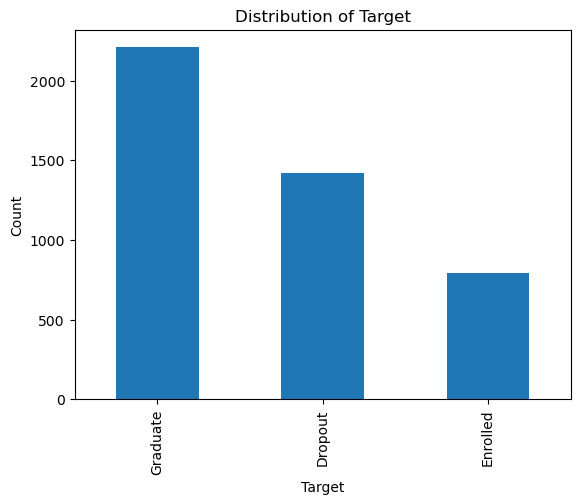

In [96]:
df["Target"].value_counts().plot(kind="bar")
plt.title("Distribution of Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

The graph shows that 'Graduate' is the largest outcome in the group in the dataset 'Dropout' also appears frequentily and 'enrolled' is the smallest of three groups

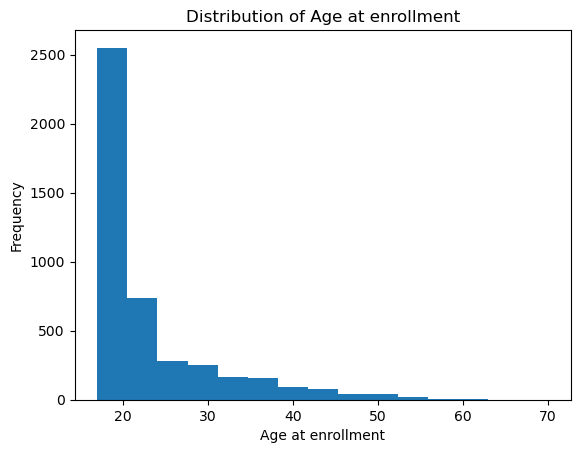

In [97]:
df["Age at enrollment"].plot(kind="hist", bins=15)
plt.title("Distribution of Age at enrollment")
plt.xlabel("Age at enrollment")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most students entered at a younger age, with the highest concentration in the lower age values.

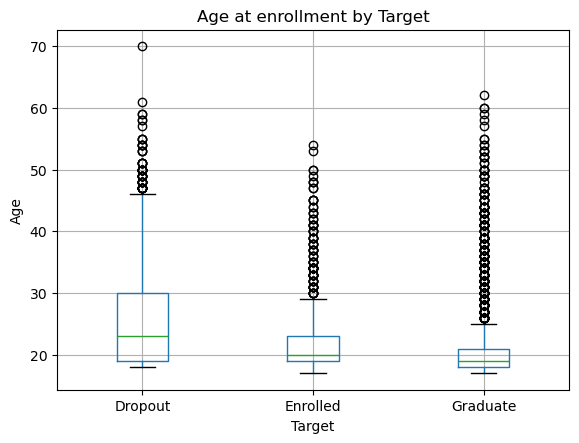

In [98]:
df.boxplot(column="Age at enrollment", by="Target")
plt.title("Age at enrollment by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Age")
plt.show()

The boxplot shows how `Age at enrollment` changes across the three outcome groups, this helps identify whether some groups tend to be younger or older than others

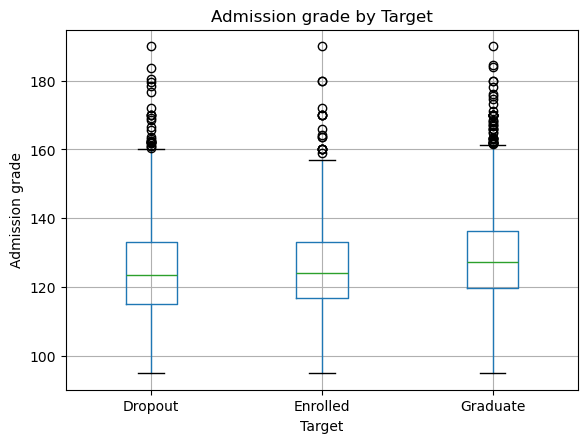

In [99]:
df.boxplot(column="Admission grade", by="Target")
plt.title("Admission grade by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Admission grade")
plt.show()

Comparing the "Admission Grade" between the three groups, the "Graduates" group appears to have slightly higher admission grades, while the "Dropouts" and "Enrolled" groups have more similar results; there are also outliers in all groups

The visualizations helped to show some useful patterns: the target groups are not evenly distributed, most students started at younger ages, and some differences can be observed in the outcome groups in variables such as age and admission grade.

## Preparing the Data for PCA

Before using PCA, the dataset needs some additional preparation steps: the target variable must be separated, the remaining missing values ​​need to be handled, and the data needs to be organized.

In [100]:
df_pca = df.copy()
df_pca["Marital status"] = pd.to_numeric(df_pca["Marital status"], errors="coerce")
df_pca = df_pca.dropna()

X = df_pca.drop("Target", axis=1)
y = df_pca["Target"]

The dataset was divided into the input variables `X` and the target variable `y`. Before PCA, `Marital status` was converted to numeric format, and rows with remaining missing values were removed

In [101]:
X.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1.0,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0,0.0,0,0,0.000000,0,10.8,1.4,1.74
1,1.0,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79
2,1.0,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,0,6.0,0,0,0.000000,0,10.8,1.4,1.74
3,1.0,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12
4,2.0,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79


The input data was checked to confirm that the `Target` column had been removed and that the remaining variables were ready for scaling

In [102]:
import sklearn.preprocessing as preproc

In [103]:
X_scaled = preproc.StandardScaler().fit_transform(X)

In [104]:
X_scaled.shape

(4411, 36)

In [105]:
from sklearn.decomposition import PCA

PCA was used to find the minimum number of components needed to retain 99.5% of the variance

In [106]:
pca_full = PCA()
pca_full.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [107]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

In [108]:
n_components_995 = np.argmax(cumulative_variance >= 0.995) + 1
n_components_995

np.int64(33)

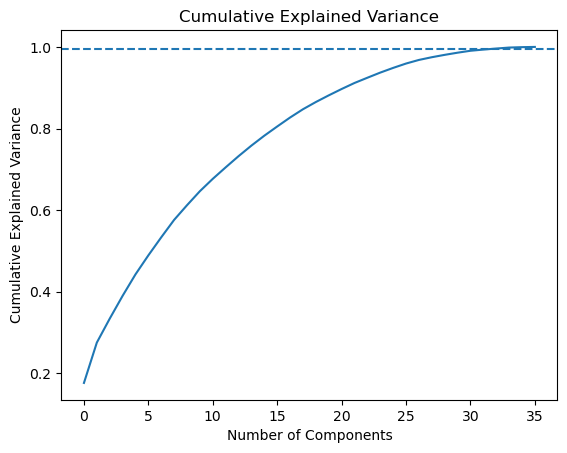

In [109]:
plt.plot(cumulative_variance)
plt.axhline(y=0.995, linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()

The variance plot shows how the amount of retained variance increases as more components are added

In [110]:
pca = PCA(n_components=n_components_995)
X_pca = pca.fit_transform(X_scaled)

In [111]:
X_pca.shape

(4411, 33)

PCA was then applied using the selected number of components this reduced the size of the input data while still retaining 99.5% of the variance

## Curse of Dimensionality

This step describes the difficulties that arise when a dataset has many variables, more columns there are, the more difficult it becomes to analyze, find patterns, and some methods may worsen

In this dataset, the curse of dimensionality is important because there are many input variables related to student information, some variables may contain similar or overlapping information, which can make the analysis more complex

This is why PCA is useful in this analysis it reduces the number of variables to a smaller set of principal components, while retaining most of the information present in the dataset

## Testing the Reduced Dataset

KNN will be used to test the reduced dataset because it is a simple classification method that helps demonstrate whether the data transformed by PCA still retains useful information

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.20, random_state=1
)

The reduced dataset was split into training and test data so that the model could be trained and then evaluated

In [114]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [115]:
predictions = model.predict(X_test)

In [116]:
print(accuracy_score(y_test, predictions))

0.7202718006795017


In [117]:
print(confusion_matrix(y_test, predictions))

[[219  25  44]
 [ 32  48  71]
 [ 29  46 369]]


The KNN model achieved an accuracy of approximately 72% on the reduced dataset its suggests that the data transformed by PCA still retained useful information, but some misclassification is still observable in the confusion matrix.